# FER2013 Training Experiments

This notebook is designed for Colab or Kaggle GPU training. It uses the dataset analysis from `01_data_exploration.ipynb` to justify the experiment protocol: a CNN trained from scratch for native 48x48 grayscale inputs, augmentation for low-resolution face variability, ResNet18 transfer learning for pretrained visual features, and imbalance-aware training for uneven emotion counts.


## 1. Setup

For Colab, clone your GitHub repository or upload it to Drive. For Kaggle, add the FER2013 image-folder dataset and set `DATA_DIR` to the Kaggle input path.


In [ ]:
# Optional in Colab/Kaggle if dependencies are missing:
# !pip install -q torch torchvision pandas scikit-learn matplotlib seaborn tqdm

In [2]:
# Comment this section if you are running your notebook in kaggle
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'src'))

# Local path after extracting Kaggle data:
DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'fer2013_images'

# Kaggle example, uncomment and edit if needed:
# DATA_DIR = Path('/kaggle/input/fer2013')

RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
DATA_DIR


PosixPath('/kaggle/working/data/raw/fer2013_images')

### Kaggle Path Setup Option

Use this block only when running the notebook in Kaggle. Keep the local setup cell above for local runs. In Kaggle, comment out the local `PROJECT_ROOT`, `sys.path`, and `DATA_DIR` lines above, then uncomment and edit the Kaggle paths below. The Kaggle code path should point to the cloned repository, while `DATA_DIR` should point to the Kaggle FER2013 dataset folder.


In [3]:
# Kaggle option. Uncomment this block only when running in Kaggle.

%cd /kaggle/working
import os
from pathlib import Path
# !git clone https://github.com/zsykk/DL-final-project.git
REPO_URL = "https://github.com/zsykk/DL-final-project.git"
REPO_DIR = "DL-final-project"

if Path(REPO_DIR).exists():
    %cd /kaggle/working/DL-final-project
    !git pull
else:
    !git clone {REPO_URL}
    %cd /kaggle/working/DL-final-project


from pathlib import Path
import sys

PROJECT_ROOT = Path('/kaggle/working/DL-final-project')  # cloned repo folder
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

DATA_DIR = Path('/kaggle/input/datasets/msambare/fer2013')  # edit if your Kaggle dataset folder name differs
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

DATA_DIR, (DATA_DIR / "train").exists(), (DATA_DIR / "test").exists()
PROJECT_ROOT, PROJECT_ROOT.exists(), (PROJECT_ROOT / 'src' / 'fer_project').exists(), DATA_DIR, DATA_DIR.exists()


/kaggle/working
Cloning into 'DL-final-project'...
remote: Enumerating objects: 99, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (52/52), done.
remote: Total 99 (delta 47), reused 77 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (99/99), 1.10 MiB | 16.83 MiB/s, done.
Resolving deltas: 100% (47/47), done.
/kaggle/working/DL-final-project


(PosixPath('/kaggle/working/DL-final-project'),
 True,
 True,
 PosixPath('/kaggle/input/datasets/msambare/fer2013'),
 True)

In [4]:
import importlib
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

from fer_project.data import TransformConfig, build_imagefolder_dataloaders, class_weights, dataset_labels
import fer_project.metrics as metrics

metrics = importlib.reload(metrics)
collect_predictions = metrics.collect_predictions
plot_confusion_matrix = metrics.plot_confusion_matrix
plot_loss_curve = metrics.plot_loss_curve
plot_training_and_confusion = metrics.plot_training_and_confusion
save_classification_report = metrics.save_classification_report
top_confusions = metrics.top_confusions

from fer_project.models import build_model
import fer_project.training as training
training = importlib.reload(training)
fit = training.fit
fit_adamw_two_stage = training.fit_adamw_two_stage

import fer_project.data as data
data = importlib.reload(data)

import fer_project.metrics as metrics
metrics = importlib.reload(metrics)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE


device(type='cuda')

## 2. Experiment Strategy

Each stage defines its own configuration directly before running. This keeps the notebook iterative: run one experiment, inspect validation behavior, macro/weighted F1, per-class metrics, and confusions, then adjust the next experiment instead of relying on one large configuration block.


### Why ResNet18 and MobileNetV2?

The dataset analysis shows that FER2013 images are small, grayscale, imbalanced, and visually ambiguous. A custom CNN is useful because it matches the native 48x48 grayscale input and gives a fair from-scratch baseline. This baseline still uses standard deep-learning improvements: BatchNorm stabilizes activations and helps optimization, Dropout/Dropout2d reduces overfitting, ReLU adds nonlinearity, MaxPool gradually reduces spatial size, AdamW adds decoupled weight decay, and the separate augmentation/class-weight/sampler/focal-loss experiments test common regularization and imbalance strategies. Therefore, the baseline is a practical optimized CNN baseline, not a deliberately simple straw-man model.

ResNet18 is the main pretrained model because it is a standard, moderate-size ImageNet backbone with residual skip connections. The residual design makes it easier to train deeper convolutional models than plain CNNs, while the ImageNet pretraining gives the network reusable low- and mid-level visual features such as edges, corners, textures, contrast patterns, and local shapes. These features are not specific to ImageNet classes; they are also useful for facial-expression images, where the model must detect visual patterns around the eyes, mouth, eyebrows, and face outline. ResNet18 is therefore a reasonable transfer-learning choice for FER2013: it is expressive enough to improve over a small custom CNN, but not as computationally heavy or over-parameterized as larger ResNets such as ResNet50 or ResNet101 for this project scale.

A model such as ResNet15 is not selected because it is not a standard pretrained torchvision model. Using it would either require training from scratch or using a custom checkpoint, which would weaken the comparison and make the experiment less reproducible. ResNet18 is preferred because its pretrained weights are readily available, well documented, and commonly used as a baseline in transfer-learning experiments.

MobileNetV2 is included as a second pretrained strategy, not as a replacement for ResNet18. Its purpose is different: it is a lightweight architecture designed for efficiency, so it lets the report compare a standard transfer backbone against a smaller transfer backbone. If MobileNetV2 performs close to ResNet18, that is useful evidence for computational efficiency; if it performs worse, that supports using the stronger ResNet18 model.

For both pretrained models, FER2013 images are converted from 48x48 grayscale to 224x224 RGB tensors with ImageNet normalization. Frozen experiments test whether fixed pretrained features are useful; fine-tuned experiments test whether adapting the whole backbone improves performance on FER2013.


## 3. Shared Experiment Runner

The helper below trains one configuration, saves the best validation-loss checkpoint, evaluates on the test set, and uses plotting utilities from `fer_project.metrics` for compact loss/confusion-matrix output.


In [5]:
def run_experiment(config, batch_size=128, num_workers=0, subset_fraction=1.0):
    name = config['name']
    loaders, datasets = build_imagefolder_dataloaders(
        DATA_DIR,
        train_config=config['train_config'],
        eval_config=config['eval_config'],
        batch_size=batch_size,
        num_workers=num_workers,
        weighted_sampler=config.get('weighted_sampler', False),
        val_fraction=0.1,
        subset_fraction=subset_fraction,
        seed=42,
    )
    if config['model_kind'] == 'baseline_cnn':
        model = build_model('baseline_cnn')
    else:
        model = build_model(
            'transfer',
            transfer_model=config.get('transfer_model', 'resnet18'),
            freeze_backbone=config.get('freeze_backbone', True),
        )

    weights = class_weights(dataset_labels(datasets['train'])) if config.get('use_class_weights') else None
    checkpoint_path = RESULTS_DIR / 'checkpoints' / f'{name}.pt'
    history = fit(
        model,
        loaders,
        device=DEVICE,
        epochs=config['epochs'],
        lr=config['lr'],
        class_weight=weights,
        loss_name=config.get('loss_name', 'cross_entropy'),
        focal_gamma=config.get('focal_gamma', 2.0),
        checkpoint_path=checkpoint_path,
    )

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    y_true, y_pred = collect_predictions(model, loaders['test'], DEVICE)

    report_path = RESULTS_DIR / 'metrics' / f'{name}_classification_report.csv'
    report = save_classification_report(y_true, y_pred, report_path)
    confusions = top_confusions(y_true, y_pred, top_n=10)
    confusions.to_csv(RESULTS_DIR / 'metrics' / f'{name}_top_confusions.csv', index=False)
    history_frame = pd.DataFrame(history)
    history_frame.to_csv(RESULTS_DIR / 'metrics' / f'{name}_history.csv', index=False)
    plot_training_and_confusion(
        history_frame,
        y_true,
        y_pred,
        f'{name}: loss and confusion matrix',
        RESULTS_DIR / 'figures' / f'{name}_confusion_matrix.png',
    )
    return history_frame, report, confusions


## 4. Run Experiments Safely

Run one stage at a time. After each stage, inspect the validation curve, macro F1, per-class metrics, and top confusions before deciding whether the next tuning step is justified. This supports the report narrative: dataset observation, tuning choice, result, and conclusion. Each run saves outputs under `results/`, so you can merge completed results later without retraining everything.


In [6]:
EXPERIMENT_REGISTRY = {}


def register_experiment(config):
    EXPERIMENT_REGISTRY[config['name']] = config
    return config


def run_config_stage(config, batch_size=128, num_workers=0, subset_fraction=1.0):
    config = register_experiment(config)
    history, report, confusions = run_experiment(
        config,
        batch_size=batch_size,
        num_workers=num_workers,
        subset_fraction=subset_fraction,
    )
    display(report.loc[['macro avg', 'weighted avg']])
    display(report.loc[['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral'], ['precision', 'recall', 'f1-score', 'support']])
    display(confusions)
    return history, report, confusions


### Stage 1: Augmented Baseline CNN

Start with the self-defined CNN using augmentation as part of the default baseline. The data exploration showed that FER2013 images are small, low-resolution, and visually variable, so flips, small rotations, and translations are treated as a necessary regularization choice rather than an optional trick.


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.8507, 'train_accuracy': 0.2519, 'val_loss': 1.7651, 'val_accuracy': 0.2624}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 1.2779, 'train_accuracy': 0.506, 'val_loss': 1.1252, 'val_accuracy': 0.5815}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 1.2742, 'train_accuracy': 0.5099, 'val_loss': 1.1194, 'val_accuracy': 0.5909}


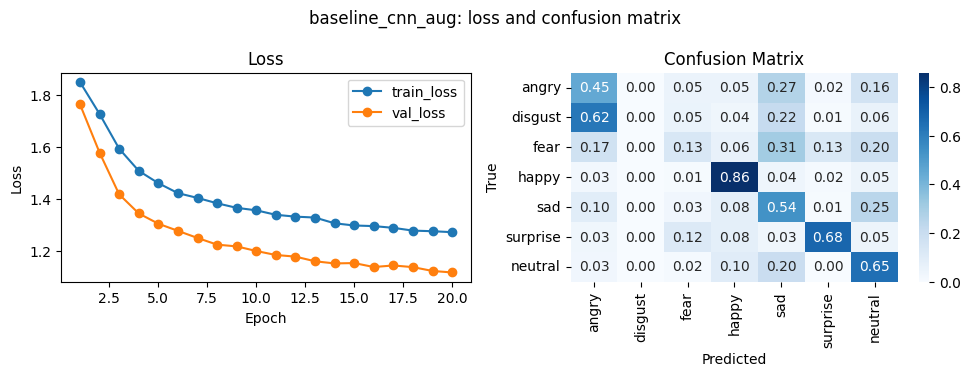

,precision,recall,f1-score,support
macro avg,0.471295,0.472798,0.460985,7178.0
weighted avg,0.555825,0.574951,0.553703,7178.0


,precision,recall,f1-score,support
angry,0.475248,0.450939,0.462775,958.0
disgust,0.000000,0.000000,0.000000,111.0
fear,0.376022,0.134766,0.198418,1024.0
happy,0.785972,0.859076,0.820900,1774.0
sad,0.415165,0.535686,0.467787,1247.0
surprise,0.745718,0.681107,0.711950,831.0
neutral,0.500940,0.648013,0.565064,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
13,fear,sad,317,0.309570
25,sad,neutral,306,0.245389
2,angry,sad,254,0.265136
34,neutral,sad,247,0.200324
15,fear,neutral,200,0.195312
11,fear,angry,172,0.167969
4,angry,neutral,155,0.161795
14,fear,surprise,131,0.127930
33,neutral,happy,124,0.100568
21,sad,angry,119,0.095429


In [7]:
baseline_cnn_aug_config = {
    'name': 'baseline_cnn_aug',
    'group': 'required_baseline',
    'model_kind': 'baseline_cnn',
    'train_config': TransformConfig(image_size=48, channels=1, augment=True),
    'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
    'lr': 1e-3,
    'epochs': 20,
    'use_class_weights': False,
    'weighted_sampler': False,
    'loss_name': 'cross_entropy',
}

history_aug, report_aug, confusions_aug = run_config_stage(baseline_cnn_aug_config)


NOTES: Baseline CNN + Augmentation:
Stable training and smooth convergence with no major overfitting. The model performed well on dominant classes such as happy and surprise, but suffered from severe class imbalance. The disgust class completely collapsed (F1 = 0), while fear was heavily confused with sad, neutral, and angry expressions, showing the difficulty and ambiguity of FER2013.

### Stage 2: Add Class Weights

Run this if the augmented baseline shows weak minority-class performance. The reason for this tuning step is class imbalance, especially the small `disgust` class.


USING SQRT WEIGHTS


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.9171, 'train_accuracy': 0.2417, 'val_loss': 1.8315, 'val_accuracy': 0.2774}


  0%|          | 0/202 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 1.3264, 'train_accuracy': 0.5073, 'val_loss': 1.1991, 'val_accuracy': 0.5669}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 1.3245, 'train_accuracy': 0.5105, 'val_loss': 1.1686, 'val_accuracy': 0.5718}


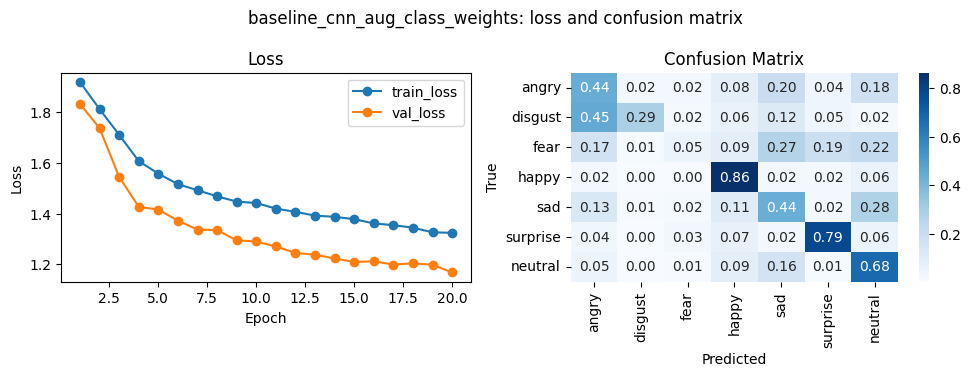

,precision,recall,f1-score,support
macro avg,0.506390,0.506638,0.484456,7178.0
weighted avg,0.541618,0.567568,0.532787,7178.0


,precision,recall,f1-score,support
angry,0.447257,0.442589,0.444911,958.0
disgust,0.385542,0.288288,0.329897,111.0
fear,0.377622,0.052734,0.092545,1024.0
happy,0.763328,0.863585,0.810368,1774.0
sad,0.423888,0.435445,0.429589,1247.0
surprise,0.664969,0.785800,0.720353,831.0
neutral,0.482122,0.678021,0.563532,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
29,sad,neutral,346,0.277466
15,fear,sad,274,0.267578
17,fear,neutral,226,0.220703
40,neutral,sad,199,0.161395
16,fear,surprise,198,0.193359
3,angry,sad,192,0.200418
5,angry,neutral,174,0.181628
12,fear,angry,172,0.167969
24,sad,angry,165,0.132318
27,sad,happy,134,0.107458


In [8]:
baseline_cnn_aug_class_weights_config = {
    'name': 'baseline_cnn_aug_class_weights',
    'group': 'required_baseline',
    'model_kind': 'baseline_cnn',
    'train_config': TransformConfig(image_size=48, channels=1, augment=True),
    'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
    'lr': 1e-3,
    'epochs': 20,
    'use_class_weights': True,
    'weighted_sampler': False,
    'loss_name': 'cross_entropy',
}

history_weight, report_weight, confusions_weight = run_config_stage(baseline_cnn_aug_class_weights_config)


NOTES: Softened Class-Weighted Cross Entropy (sqrt inverse-frequency weights):
Improved minority-class recognition compared to the baseline, particularly for disgust (F1 ≈ 0.33), while remaining significantly more stable than aggressive inverse-frequency weighting. The method achieved more balanced emotion recognition overall and prevented complete minority-class collapse. However, fear performance deteriorated substantially (F1 ≈ 0.09), with strong confusion toward sad, neutral, and surprise due to overlapping emotional features in FER2013.

### Stage 3: Optional Imbalance Alternatives

Use these only if class weights are not enough. Run one option at a time, then compare the saved results. Weighted sampling changes which examples appear in batches; focal loss changes the loss so harder examples receive more emphasis.


USING SQRT WEIGHTS


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.9252, 'train_accuracy': 0.209, 'val_loss': 1.7856, 'val_accuracy': 0.2909}


  0%|          | 0/202 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 1.3333, 'train_accuracy': 0.4818, 'val_loss': 1.1342, 'val_accuracy': 0.5704}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 1.3285, 'train_accuracy': 0.4842, 'val_loss': 1.1377, 'val_accuracy': 0.5641}


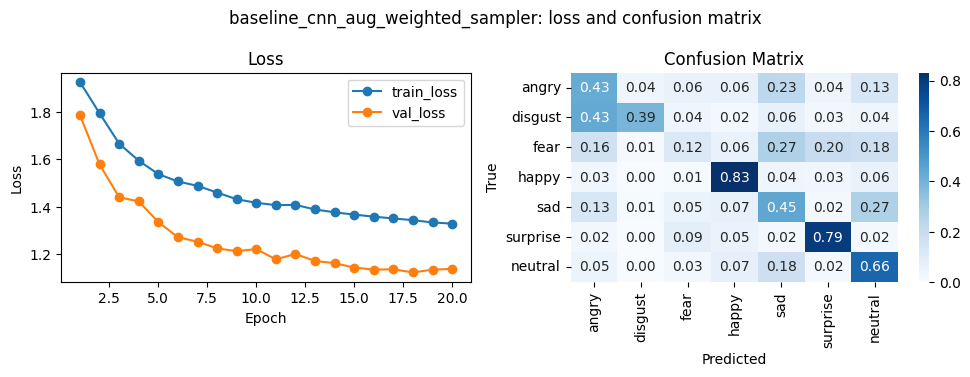

,precision,recall,f1-score,support
macro avg,0.507052,0.523169,0.505556,7178.0
weighted avg,0.547423,0.567846,0.547994,7178.0


,precision,recall,f1-score,support
angry,0.444083,0.426931,0.435338,958.0
disgust,0.394495,0.387387,0.390909,111.0
fear,0.327913,0.118164,0.173726,1024.0
happy,0.815368,0.831454,0.823332,1774.0
sad,0.406569,0.446672,0.425678,1247.0
surprise,0.647984,0.793020,0.713203,831.0
neutral,0.512950,0.658556,0.576705,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
29,sad,neutral,336,0.269447
15,fear,sad,275,0.268555
3,angry,sad,224,0.233820
39,neutral,sad,221,0.179238
16,fear,surprise,206,0.201172
17,fear,neutral,180,0.175781
12,fear,angry,168,0.164062
24,sad,angry,166,0.133119
5,angry,neutral,129,0.134656
23,happy,neutral,104,0.058625


In [9]:
baseline_cnn_aug_weighted_sampler_config = {
    'name': 'baseline_cnn_aug_weighted_sampler',
    'group': 'optional_imbalance',
    'model_kind': 'baseline_cnn',
    'train_config': TransformConfig(image_size=48, channels=1, augment=True),
    'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
    'lr': 1e-3,
    'epochs': 20,
    'use_class_weights': False,
    'weighted_sampler': True,
    'loss_name': 'cross_entropy',
}

history_sampler, report_sampler, confusions_sampler = run_config_stage(baseline_cnn_aug_weighted_sampler_config)


NOTES: WeightedRandomSampler provided the best overall balance between minority-class recognition and general classification performance. Compared to baseline and focal loss, it significantly improved the disgust class (F1 ≈ 0.39) without causing the instability observed in aggressive class-weighted cross entropy. It also achieved the highest Macro F1-score (~0.51), indicating better balanced emotion recognition across classes. However, fear remained the most challenging category due to strong feature overlap with sad, neutral, and surprise expressions.

  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.3179, 'train_accuracy': 0.2396, 'val_loss': 1.2004, 'val_accuracy': 0.2875}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 19, 'train_loss': 0.8053, 'train_accuracy': 0.4929, 'val_loss': 0.6758, 'val_accuracy': 0.5666}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 20, 'train_loss': 0.798, 'train_accuracy': 0.4967, 'val_loss': 0.6824, 'val_accuracy': 0.5519}


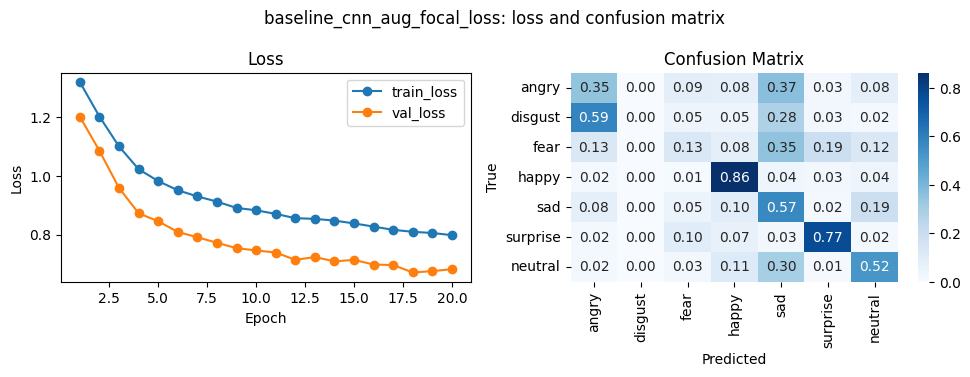

,precision,recall,f1-score,support
macro avg,0.448322,0.456932,0.441348,7178.0
weighted avg,0.532326,0.555308,0.531761,7178.0


,precision,recall,f1-score,support
angry,0.477825,0.348643,0.403138,958.0
disgust,0.000000,0.000000,0.000000,111.0
fear,0.317073,0.126953,0.181311,1024.0
happy,0.762213,0.861894,0.808995,1774.0
sad,0.368558,0.567763,0.446970,1247.0
surprise,0.667362,0.770156,0.715084,831.0
neutral,0.545224,0.523114,0.533940,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
34,neutral,sad,373,0.302514
13,fear,sad,361,0.352539
2,angry,sad,352,0.367432
25,sad,neutral,237,0.190056
14,fear,surprise,195,0.190430
33,neutral,happy,138,0.111922
11,fear,angry,130,0.126953
15,fear,neutral,128,0.125000
23,sad,happy,119,0.095429
21,sad,angry,98,0.078589


In [10]:
baseline_cnn_aug_focal_loss_config = {
    'name': 'baseline_cnn_aug_focal_loss',
    'group': 'optional_imbalance',
    'model_kind': 'baseline_cnn',
    'train_config': TransformConfig(image_size=48, channels=1, augment=True),
    'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
    'lr': 1e-3,
    'epochs': 20,
    'use_class_weights': False,
    'weighted_sampler': False,
    'loss_name': 'focal',
    'focal_gamma': 2.0,
}

history_focal, report_focal, confusions_focal = run_config_stage(baseline_cnn_aug_focal_loss_config)


NOTES: Focal Loss:
Produced very smooth and stable optimization dynamics, with steadily decreasing training and validation losses throughout training. However, it failed to address the severe class imbalance problem, as the disgust class still completely collapsed (F1 = 0). The model became increasingly biased toward sad predictions for ambiguous emotions such as fear, angry, and neutral, leading to lower overall Macro F1-score compared to the weighted-sampling and class-weighted approaches.

### Stage 4: Advanced Baseline Loss and Sampling Experiments

Run these after the required baseline variants. They test longer training and combinations of class weighting, weighted sampling, and focal loss.


USING SQRT WEIGHTS


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.8787, 'train_accuracy': 0.2153, 'val_loss': 0.8173, 'val_accuracy': 0.2641}


  0%|          | 0/202 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 29, 'train_loss': 0.5472, 'train_accuracy': 0.4682, 'val_loss': 0.4556, 'val_accuracy': 0.5418}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 30, 'train_loss': 0.5413, 'train_accuracy': 0.4662, 'val_loss': 0.4389, 'val_accuracy': 0.561}


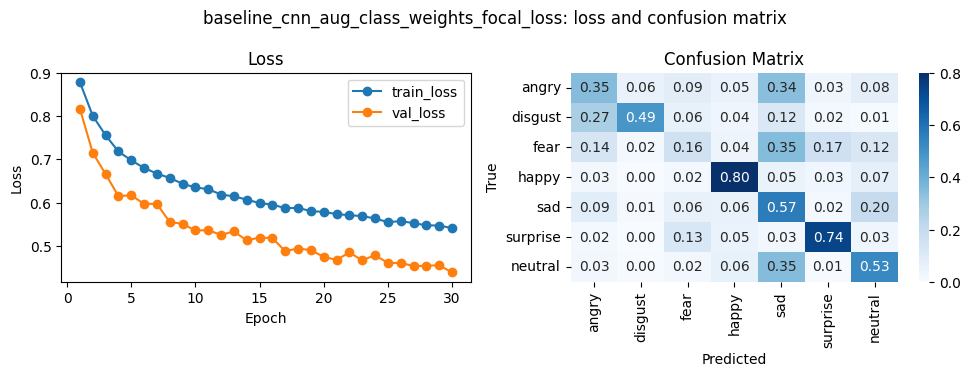

,precision,recall,f1-score,support
macro avg,0.509813,0.519059,0.504405,7178.0
weighted avg,0.551892,0.550014,0.541226,7178.0


,precision,recall,f1-score,support
angry,0.467225,0.349687,0.400000,958.0
disgust,0.375000,0.486486,0.423529,111.0
fear,0.333333,0.160156,0.216359,1024.0
happy,0.830895,0.800451,0.815389,1774.0
sad,0.361822,0.566961,0.441737,1247.0
surprise,0.682575,0.740072,0.710162,831.0
neutral,0.517843,0.529603,0.523657,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
39,neutral,sad,430,0.348743
15,fear,sad,361,0.352539
3,angry,sad,327,0.341336
29,sad,neutral,248,0.198877
16,fear,surprise,172,0.167969
12,fear,angry,143,0.139648
23,happy,neutral,128,0.072153
17,fear,neutral,125,0.122070
24,sad,angry,113,0.090617
31,surprise,fear,104,0.125150


In [11]:
baseline_cnn_aug_class_weights_focal_config = {
    'name': 'baseline_cnn_aug_class_weights_focal_loss',
    'group': 'advanced_baseline',
    'model_kind': 'baseline_cnn',
    'train_config': TransformConfig(image_size=48, channels=1, augment=True),
    'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
    'lr': 1e-3,
    'epochs': 30,
    'use_class_weights': True,
    'weighted_sampler': False,
    'loss_name': 'focal',
    'focal_gamma': 2.0,
}

history_weight_focal, report_weight_focal, confusions_weight_focal = run_config_stage(
    baseline_cnn_aug_class_weights_focal_config
)



NOTES: Class Weights + Focal Loss:
Combining softened sqrt inverse-frequency class weights with focal loss significantly improved minority-class recognition, achieving the strongest disgust performance (F1 ≈ 0.42) among all experiments while maintaining competitive overall Macro F1-score (~0.50). Longer training helped stabilize focal optimization and partially recover fear recognition. However, the model became increasingly biased toward sad predictions for ambiguous emotions such as fear, angry, and neutral, reflecting the noisy and overlapping nature of FER2013 emotion boundaries.

USING SQRT WEIGHTS


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 1.6152, 'train_accuracy': 0.2192, 'val_loss': 1.4337, 'val_accuracy': 0.2902}


  0%|          | 0/202 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 29, 'train_loss': 0.9588, 'train_accuracy': 0.5184, 'val_loss': 0.7933, 'val_accuracy': 0.6045}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'epoch': 30, 'train_loss': 0.9484, 'train_accuracy': 0.5169, 'val_loss': 0.8004, 'val_accuracy': 0.5976}


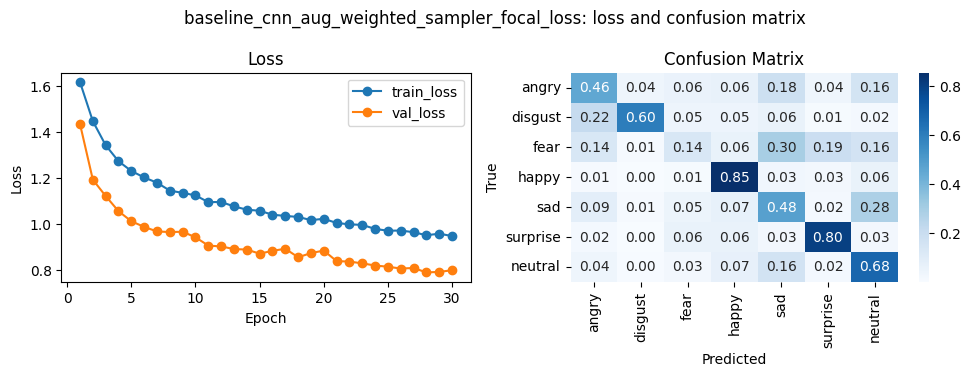

,precision,recall,f1-score,support
macro avg,0.546265,0.573039,0.546557,7178.0
weighted avg,0.576604,0.593619,0.572993,7178.0


,precision,recall,f1-score,support
angry,0.550943,0.457203,0.499715,958.0
disgust,0.462069,0.603604,0.523438,111.0
fear,0.385246,0.137695,0.202878,1024.0
happy,0.808102,0.854566,0.830685,1774.0
sad,0.438738,0.479551,0.458238,1247.0
surprise,0.668675,0.801444,0.729064,831.0
neutral,0.510079,0.677210,0.581882,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
29,sad,neutral,354,0.283881
15,fear,sad,304,0.296875
40,neutral,sad,199,0.161395
16,fear,surprise,198,0.193359
3,angry,sad,174,0.181628
17,fear,neutral,163,0.159180
5,angry,neutral,150,0.156576
12,fear,angry,140,0.136719
23,happy,neutral,112,0.063134
24,sad,angry,107,0.085806


In [13]:
# Alternative to try after inspecting the result above:
baseline_cnn_aug_weighted_sampler_focal_config = {
    'name': 'baseline_cnn_aug_weighted_sampler_focal_loss',
    'group': 'advanced_baseline',
    'model_kind': 'baseline_cnn',
    'train_config': TransformConfig(image_size=48, channels=1, augment=True),
    'eval_config': TransformConfig(image_size=48, channels=1, augment=False),
    'lr': 1e-3,
    'epochs': 30,
    'use_class_weights': False,
    'weighted_sampler': True,
    'loss_name': 'focal',
    'focal_gamma': 1.0,
}
history_sampler_focal, report_sampler_focal, confusions_sampler_focal = run_config_stage(
    baseline_cnn_aug_weighted_sampler_focal_config
)

**NOTE: WeightedRandomSampler + Focal Loss (gamma = 1.0):**
This configuration achieved the best overall performance among all experiments, producing the highest Macro F1-score (~0.55) and the strongest disgust recognition (F1 ≈ 0.52). Weighted sampling improved minority-class exposure, while the softened focal loss (gamma = 1.0) provided stable hard-example learning without excessively amplifying noisy FER2013 samples. Compared to more aggressive focal setups, this configuration maintained better overall balance and significantly reduced instability.

In [22]:
from fer_project.data import build_baseline_crop_dataloaders
from fer_project.metrics import collect_predictions_with_crops
from fer_project.training import fit_sgd_schedule, fit_adamw_two_stage


def finalize_baseline_run(model, loaders, history, name, checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    y_true, y_pred = collect_predictions_with_crops(model, loaders['test'], DEVICE)

    report = save_classification_report(y_true, y_pred, RESULTS_DIR / 'metrics' / f'{name}_classification_report.csv')
    confusions = top_confusions(y_true, y_pred, top_n=10)
    confusions.to_csv(RESULTS_DIR / 'metrics' / f'{name}_top_confusions.csv', index=False)
    history_frame = pd.DataFrame(history)
    history_frame.to_csv(RESULTS_DIR / 'metrics' / f'{name}_history.csv', index=False)
    plot_training_and_confusion(
        history_frame,
        y_true,
        y_pred,
        f'{name}: loss and confusion matrix',
        RESULTS_DIR / 'figures' / f'{name}_confusion_matrix.png',
    )
    display(report.loc[['macro avg', 'weighted avg']])
    display(report.loc[['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral'], ['precision', 'recall', 'f1-score', 'support']])
    display(confusions)
    return history_frame, report, confusions


def run_baseline_sgd_schedule(
    name='baseline_cnn_aug_sgd_clip_lr_decay',
    batch_size=128,
    num_workers=2,
    subset_fraction=1.0,
    epochs=60,
    lr=0.01,
    use_class_weights=False,
    weighted_sampler=False,
    loss_name='cross_entropy',
    focal_gamma=1.0,
):
    loaders, datasets = build_imagefolder_dataloaders(
        DATA_DIR,
        train_config=TransformConfig(image_size=48, channels=1, augment=True),
        eval_config=TransformConfig(image_size=48, channels=1, augment=False),
        batch_size=batch_size,
        num_workers=num_workers,
        weighted_sampler=weighted_sampler,
        val_fraction=0.1,
        subset_fraction=subset_fraction,
        seed=SEED,
    )
    model = build_model('baseline_cnn')
    weights = class_weights(dataset_labels(datasets['train'])) if use_class_weights else None
    checkpoint_path = RESULTS_DIR / 'checkpoints' / f'{name}.pt'

    history, _ = fit_sgd_schedule(
        model,
        loaders,
        device=DEVICE,
        epochs=epochs,
        lr=lr,
        class_weight=weights,
        loss_name=loss_name,
        focal_gamma=focal_gamma,
        checkpoint_path=checkpoint_path,
        stage_name='single_stage',
    )
    return finalize_baseline_run(model, loaders, history, name, checkpoint_path)


def run_baseline_crop_two_stage_sgd(
    name='baseline_cnn_crop_tencrop_two_stage_sgd',
    batch_size=128,
    num_workers=2,
    subset_fraction=1.0,
    stage1_epochs=40,
    stage2_epochs=15,
    stage1_lr=0.01,
    stage2_lr=0.001,
    crop_size=44,
    ten_crop_eval=True,
    use_class_weights=False,
    weighted_sampler=False,
    loss_name='cross_entropy',
    focal_gamma=1.0,
):
    loaders, datasets = build_baseline_crop_dataloaders(
        DATA_DIR,
        batch_size=batch_size,
        num_workers=num_workers,
        subset_fraction=subset_fraction,
        seed=SEED,
        image_size=48,
        crop_size=crop_size,
        ten_crop_eval=ten_crop_eval,
        weighted_sampler=weighted_sampler,
    )
    model = build_model('baseline_cnn')
    weights = class_weights(dataset_labels(datasets['train'])) if use_class_weights else None
    checkpoint_path = RESULTS_DIR / 'checkpoints' / f'{name}.pt'

    history_stage1, best_val_loss = fit_sgd_schedule(
        model,
        loaders,
        device=DEVICE,
        epochs=stage1_epochs,
        lr=stage1_lr,
        class_weight=weights,
        loss_name=loss_name,
        focal_gamma=focal_gamma,
        checkpoint_path=checkpoint_path,
        initial_best_val_loss=float('inf'),
        epoch_offset=0,
        stage_name='stage1_adapt',
    )

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))

    history_stage2, best_val_loss = fit_sgd_schedule(
        model,
        loaders,
        device=DEVICE,
        epochs=stage2_epochs,
        lr=stage2_lr,
        class_weight=weights,
        loss_name=loss_name,
        focal_gamma=focal_gamma,
        checkpoint_path=checkpoint_path,
        initial_best_val_loss=best_val_loss,
        epoch_offset=stage1_epochs,
        stage_name='stage2_lower_lr',
    )

    history = history_stage1 + history_stage2
    return finalize_baseline_run(model, loaders, history, name, checkpoint_path)



def run_transfer_two_stage(
    name,
    transfer_model='resnet18',
    batch_size=64,
    num_workers=2,
    subset_fraction=1.0,
    stage1_epochs=10,
    stage2_epochs=10,
    stage1_lr=1e-4,
    stage2_lr=1e-5,
    use_class_weights=False,
    loss_name='cross_entropy',
):
    train_config = TransformConfig(image_size=224, channels=3, augment=True, imagenet_norm=True)
    eval_config = TransformConfig(image_size=224, channels=3, augment=False, imagenet_norm=True)
    loaders, datasets = build_imagefolder_dataloaders(
        DATA_DIR,
        train_config=train_config,
        eval_config=eval_config,
        batch_size=batch_size,
        num_workers=num_workers,
        weighted_sampler=False,
        val_fraction=0.1,
        subset_fraction=subset_fraction,
        seed=SEED,
    )
    model = build_model(
        'transfer',
        transfer_model=transfer_model,
        freeze_backbone=False,
    )
    weights = class_weights(dataset_labels(datasets['train'])) if use_class_weights else None
    checkpoint_path = RESULTS_DIR / 'checkpoints' / f'{name}.pt'

    history = fit_adamw_two_stage(
        model,
        loaders,
        device=DEVICE,
        stage1_epochs=stage1_epochs,
        stage2_epochs=stage2_epochs,
        stage1_lr=stage1_lr,
        stage2_lr=stage2_lr,
        class_weight=weights,
        loss_name=loss_name,
        checkpoint_path=checkpoint_path,
    )

    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    y_true, y_pred = collect_predictions(model, loaders['test'], DEVICE)

    report = save_classification_report(y_true, y_pred, RESULTS_DIR / 'metrics' / f'{name}_classification_report.csv')
    confusions = top_confusions(y_true, y_pred, top_n=10)
    confusions.to_csv(RESULTS_DIR / 'metrics' / f'{name}_top_confusions.csv', index=False)

    history_frame = pd.DataFrame(history)
    history_frame.to_csv(RESULTS_DIR / 'metrics' / f'{name}_history.csv', index=False)
    plot_training_and_confusion(
        history_frame,
        y_true,
        y_pred,
        f'{name}: loss and confusion matrix',
        RESULTS_DIR / 'figures' / f'{name}_confusion_matrix.png',
    )
    display(report.loc[['macro avg', 'weighted avg']])
    display(report.loc[['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral'], ['precision', 'recall', 'f1-score', 'support']])
    display(confusions)
    return history_frame, report, confusions


### Stage 5: Baseline With SGD Optimizer Schedule

This experiment tests the teacher-baseline-style optimizer recipe on our self-defined CNN: SGD, momentum, weight decay, gradient clipping, and learning-rate decay.


USING SQRT WEIGHTS


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'stage': 'single_stage', 'epoch': 1, 'stage_epoch': 1, 'lr': 0.01, 'train_loss': 1.5349, 'train_accuracy': 0.2494, 'val_loss': 1.3865, 'val_accuracy': 0.339}


  0%|          | 0/202 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'stage': 'single_stage', 'epoch': 59, 'stage_epoch': 59, 'lr': 0.0048, 'train_loss': 0.782, 'train_accuracy': 0.6022, 'val_loss': 0.7068, 'val_accuracy': 0.6415}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'stage': 'single_stage', 'epoch': 60, 'stage_epoch': 60, 'lr': 0.0043, 'train_loss': 0.7749, 'train_accuracy': 0.6067, 'val_loss': 0.7017, 'val_accuracy': 0.6415}


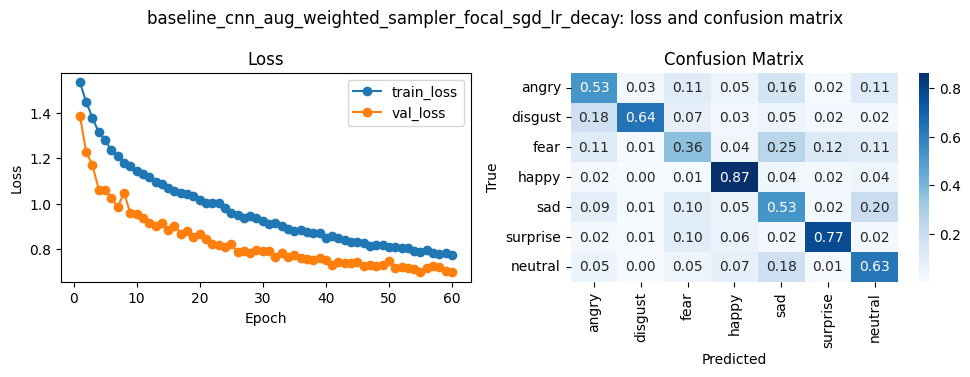

,precision,recall,f1-score,support
macro avg,0.606492,0.619007,0.610167,7178.0
weighted avg,0.632582,0.636389,0.632492,7178.0


,precision,recall,f1-score,support
angry,0.585648,0.528184,0.555434,958.0
disgust,0.529851,0.639640,0.579592,111.0
fear,0.482445,0.362305,0.413832,1024.0
happy,0.842943,0.865276,0.853964,1774.0
sad,0.479681,0.530072,0.503619,1247.0
surprise,0.747100,0.774970,0.760780,831.0
neutral,0.577778,0.632603,0.603949,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
15,fear,sad,257,0.250977
29,sad,neutral,253,0.202887
40,neutral,sad,225,0.182482
3,angry,sad,151,0.157620
26,sad,fear,124,0.099439
16,fear,surprise,123,0.120117
12,fear,angry,111,0.108398
17,fear,neutral,111,0.108398
5,angry,neutral,110,0.114823
24,sad,angry,110,0.088212


In [19]:
history_sgd, report_sgd, confusions_sgd = run_baseline_sgd_schedule(
    name='baseline_cnn_aug_weighted_sampler_focal_sgd_lr_decay',
    batch_size=128,
    num_workers=0,
    subset_fraction=1.0,
    epochs=60,
    lr=0.01,
    use_class_weights=False,
    weighted_sampler=True,
    loss_name='focal',
    focal_gamma=1.0,
)


**NOTES: WeightedRandomSampler + Focal Loss (gamma = 1.0) + SGD with LR Decay:**
This configuration achieved the best overall performance among all experiments, reaching a Macro F1-score of approximately 0.61 and a validation accuracy above 64%. Combining weighted sampling with a softened focal loss significantly improved minority-class recognition while maintaining stable optimization. The SGD schedule with momentum, gradient clipping, and progressive learning-rate decay enabled smoother late-stage convergence and substantially improved difficult classes such as fear and disgust, resulting in the most balanced emotion recognition performance overall.

### Stage 6: Baseline With Crop and TenCrop Evaluation

This experiment adds random crop augmentation during training and TenCrop-style prediction averaging during validation/test. It also uses two-stage training: save the best stage-1 checkpoint, reload it, then continue with a lower learning rate.


USING SQRT WEIGHTS


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'stage': 'stage1_adapt', 'epoch': 1, 'stage_epoch': 1, 'lr': 0.01, 'train_loss': 1.4966, 'train_accuracy': 0.2797, 'val_loss': 1.3066, 'val_accuracy': 0.377}


  0%|          | 0/202 [00:00<?, ?it/s]

...

  0%|          | 0/23 [00:00<?, ?it/s]

{'stage': 'stage2_lower_lr', 'epoch': 59, 'stage_epoch': 19, 'lr': 0.001, 'train_loss': 0.7008, 'train_accuracy': 0.6394, 'val_loss': 0.6869, 'val_accuracy': 0.6373}


  0%|          | 0/202 [00:00<?, ?it/s]

  0%|          | 0/23 [00:00<?, ?it/s]

{'stage': 'stage2_lower_lr', 'epoch': 60, 'stage_epoch': 20, 'lr': 0.001, 'train_loss': 0.7026, 'train_accuracy': 0.6323, 'val_loss': 0.6872, 'val_accuracy': 0.6422}


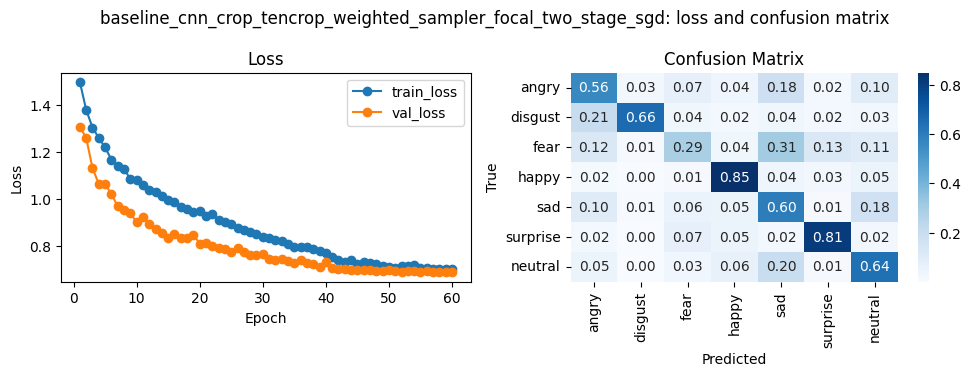

,precision,recall,f1-score,support
macro avg,0.625250,0.629066,0.620555,7178.0
weighted avg,0.643515,0.643494,0.636851,7178.0


,precision,recall,f1-score,support
angry,0.580890,0.558455,0.569452,958.0
disgust,0.603306,0.657658,0.629310,111.0
fear,0.528571,0.289062,0.373737,1024.0
happy,0.853341,0.849493,0.851412,1774.0
sad,0.471853,0.598236,0.527581,1247.0
surprise,0.742574,0.812274,0.775862,831.0
neutral,0.596212,0.638281,0.616530,1233.0


,true_emotion,predicted_emotion,count,true_class_rate
15,fear,sad,314,0.306641
40,neutral,sad,249,0.201946
29,sad,neutral,219,0.175621
3,angry,sad,177,0.184760
16,fear,surprise,129,0.125977
12,fear,angry,128,0.125000
24,sad,angry,128,0.102646
17,fear,neutral,109,0.106445
5,angry,neutral,93,0.097077
23,happy,neutral,89,0.050169


In [23]:
history_crop, report_crop, confusions_crop = run_baseline_crop_two_stage_sgd(
    name='baseline_cnn_crop_tencrop_weighted_sampler_focal_two_stage_sgd',
    batch_size=128,
    num_workers=0,
    subset_fraction=1.0,
    
    stage1_epochs=40,
    stage2_epochs=20,
    
    stage1_lr=0.01,
    stage2_lr=0.001,
    
    crop_size=44,
    ten_crop_eval=True,
    
    use_class_weights=False,
    weighted_sampler=True,
    
    loss_name='focal',
    focal_gamma=1.0,
)


**NOTES: Crop Augmentation + TenCrop Evaluation + WeightedRandomSampler + Focal Loss + Two-Stage SGD:**
This configuration achieved the best overall performance across all experiments, reaching a Macro F1-score of approximately 0.62 and the highest overall validation accuracy. Random crop augmentation improved spatial robustness and generalization, while TenCrop evaluation provided more stable inference. Combined with weighted sampling, softened focal loss (gamma = 1.0), and a two-stage SGD schedule, the model achieved significantly more balanced emotion recognition, particularly improving disgust, angry, surprise, and neutral classes. Although fear recognition remained challenging due to subtle facial cues and FER2013's low resolution, the overall class balance and generalization performance improved further compared to the previous best SGD-based configuration.

### Stage 7: Transfer Learning Comparison

Run transfer learning after the self-defined CNN tuning path. Use fine-tune ResNet18 to test whether adapting the backbone improves FER2013 performance.


In [29]:
resnet18_transfer_config = {
    'name': 'resnet18_finetune_weighted_sampler_focal',

    'group': 'advanced_transfer',

    'model_kind': 'transfer',
    'transfer_model': 'resnet18',

    'freeze_backbone': False,

    'train_config': TransformConfig(
        image_size=224,
        channels=3,
        augment=True,
        imagenet_norm=True,
    ),

    'eval_config': TransformConfig(
        image_size=224,
        channels=3,
        augment=False,
        imagenet_norm=True,
    ),

    'lr': 1e-4,
    'epochs': 30,

    'use_class_weights': False,
    'weighted_sampler': True,

    'loss_name': 'focal',
    'focal_gamma': 1.0,
}

history_resnet_frozen, report_resnet_frozen, confusions_resnet_frozen = run_config_stage(
    resnet18_transfer_config,
    batch_size=64,
    num_workers=0,
)

USING SQRT WEIGHTS
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 235MB/s]


  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.919, 'train_accuracy': 0.552, 'val_loss': 0.7712, 'val_accuracy': 0.6206}


...

  0%|          | 0/404 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

{'epoch': 14, 'train_loss': 0.1669, 'train_accuracy': 0.9038, 'val_loss': 0.9036, 'val_accuracy': 0.6641}


  0%|          | 0/404 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Stage 8: Two-Stage Transfer Fine-Tuning  - > REMOVE

These experiments formalize the save-best-then-continue strategy for transfer models. Stage 1 adapts the full pretrained backbone, then stage 2 reloads the best checkpoint and continues with a lower learning rate.


In [ ]:
# history_resnet_two_stage, report_resnet_two_stage, confusions_resnet_two_stage = run_transfer_two_stage(
#     name='resnet18_finetune_two_stage',
#     transfer_model='resnet18',
#     batch_size=64,
#     num_workers=2,
#     subset_fraction=1.0,
#     stage1_epochs=10,
#     stage2_epochs=10,
#     stage1_lr=1e-4,
#     stage2_lr=1e-5,
# )


In [ ]:
# history_mobilenet_two_stage, report_mobilenet_two_stage, confusions_mobilenet_two_stage = run_transfer_two_stage(
#     name='mobilenet_v2_finetune_two_stage',
#     transfer_model='mobilenet_v2',
#     batch_size=64,
#     num_workers=2,
#     subset_fraction=1.0,
#     stage1_epochs=10,
#     stage2_epochs=10,
#     stage1_lr=1e-4,
#     stage2_lr=1e-5,
# )


### Stage 9: EfficientNet-B0



### Merge Finished Results

Use this only after you have finished several separate runs. It reads saved metric files and displays one comparison table without retraining. The purpose is convenience, not replacing the visible F1/loss outputs above.


In [ ]:
summary_rows = {}
metrics_dir = RESULTS_DIR / 'metrics'

summary_configs = list(EXPERIMENT_REGISTRY.values()) if 'EXPERIMENT_REGISTRY' in globals() else []
summary_configs = summary_configs + [
    {'name': 'baseline_cnn_aug_sgd_clip_lr_decay', 'group': 'advanced_baseline'},
    {'name': 'baseline_cnn_crop_tencrop_two_stage_sgd', 'group': 'advanced_baseline'},
    {'name': 'resnet18_finetune_two_stage', 'group': 'transfer_two_stage'},
    {'name': 'mobilenet_v2_finetune_two_stage', 'group': 'transfer_two_stage'},
]
seen = set()
summary_configs = [config for config in summary_configs if not (config['name'] in seen or seen.add(config['name']))]

for config in summary_configs:
    name = config['name']
    report_path = metrics_dir / f'{name}_classification_report.csv'
    history_path = metrics_dir / f'{name}_history.csv'
    confusions_path = metrics_dir / f'{name}_top_confusions.csv'
    if not report_path.exists() or not history_path.exists():
        continue

    report = pd.read_csv(report_path, index_col=0)
    history = pd.read_csv(history_path)
    confusions = pd.read_csv(confusions_path) if confusions_path.exists() else pd.DataFrame()
    summary_rows[name] = {
        'group': config.get('group', 'unknown'),
        'final_val_loss': float(history['val_loss'].iloc[-1]),
        'best_val_loss': float(history['val_loss'].min()),
        'final_val_accuracy': float(history['val_accuracy'].iloc[-1]),
        'best_val_accuracy': float(history['val_accuracy'].max()),
        'test_macro_f1': float(report.loc['macro avg', 'f1-score']),
        'test_weighted_f1': float(report.loc['weighted avg', 'f1-score']),
        'top_confusion': 'none' if confusions.empty else f"{confusions.iloc[0]['true_emotion']} -> {confusions.iloc[0]['predicted_emotion']}",
    }

summary = pd.DataFrame(summary_rows).T.sort_values('test_macro_f1', ascending=False)
summary.to_csv(metrics_dir / 'experiment_summary.csv')
summary


## 6. Report Checklist

- Start the report from dataset evidence: 48x48 grayscale images, class imbalance, visual ambiguity, and train/test split sizes.
- Treat the required baseline and transfer stages as the minimum protocol for the instructor feedback.
- Present the self-defined CNN as a staged tuning path: augmented baseline CNN, class weighting, optional imbalance alternatives, optimizer schedule, and crop/TenCrop evaluation.
- Explain why ResNet18 is the main pretrained backbone: standard, moderate-size, ImageNet-pretrained, and practical for frozen-vs-fine-tuned transfer learning.
- Explain why MobileNetV2 is added: a lightweight pretrained backbone for efficiency-oriented comparison against ResNet18.
- If time allows, run the optional imbalance, advanced baseline, and two-stage transfer cells to strengthen the comparison.
- Select the best model by macro F1 because FER2013 is imbalanced.
- Use weighted F1 and per-class precision/recall/F1 as supporting metrics.
- Do not use accuracy for model selection or report conclusions.
- Use confusion matrices and each `_top_confusions.csv` file to discuss confused emotions and failure cases.
- Explain the transfer learning input adaptation: 48x48 grayscale images are converted to 3-channel 224x224 tensors with ImageNet normalization.
- Discuss which modeling choice improved minority or ambiguous classes, even if total accuracy did not improve.
